# Entrenamiento CNN - Male and Female Faces Dataset

Este notebook entrena una red neuronal convolucional desde cero para clasificación binaria de rostros en las clases `male` y `female`.

El objetivo principal es generar un archivo `model.keras` compatible con el backend FastAPI del proyecto.

El flujo implementado es:

1. Exploración del dataset.
2. Preprocesamiento de imágenes RGB.
3. Redimensionamiento a `224x224`.
4. Normalización a `[0, 1]`.
5. Partición en entrenamiento, validación y prueba.
6. Construcción de una CNN desde cero.
7. Entrenamiento y evaluación.
8. Curvas de entrenamiento.
9. Matriz de confusión.
10. Grad-CAM.
11. Saliency Map.
12. Guardado del modelo en `backend/models/model.keras`.

## 1. Imports y configuración general

In [2]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [20]:
# Reproducibilidad
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Configuración del dataset y del modelo
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

# Detectar raíz del proyecto.
# Si corres este notebook desde la carpeta notebooks/, PROJECT_ROOT será la carpeta padre.
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "backend" / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "model.keras"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("MODEL_PATH:", MODEL_PATH)
print("FIGURES_DIR:", FIGURES_DIR)

PROJECT_ROOT: /Users/niko/Documents/Projekte/models/cnn-gender-classifier
DATA_DIR: /Users/niko/Documents/Projekte/models/cnn-gender-classifier/data
MODEL_PATH: /Users/niko/Documents/Projekte/models/cnn-gender-classifier/backend/models/model.keras
FIGURES_DIR: /Users/niko/Documents/Projekte/models/cnn-gender-classifier/reports/figures


## 2. Verificación de estructura del dataset

La estructura esperada es:

```txt
data/
├── female/
└── male/
```

In [5]:
expected_classes = ["female", "male"]

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"No se encontró la carpeta {DATA_DIR}. "
        "Crea una carpeta data/ con las subcarpetas female/ y male/."
    )

for class_name in expected_classes:
    class_dir = DATA_DIR / class_name
    if not class_dir.exists():
        raise FileNotFoundError(f"No se encontró la carpeta esperada: {class_dir}")

image_extensions = {".jpg", ".jpeg", ".png", ".webp"}

dataset_summary = []

for class_name in expected_classes:
    class_dir = DATA_DIR / class_name
    image_files = [
        file for file in class_dir.rglob("*")
        if file.suffix.lower() in image_extensions
    ]
    dataset_summary.append({
        "class": class_name,
        "num_images": len(image_files)
    })

summary_df = pd.DataFrame(dataset_summary)
summary_df

,class,num_images
0,female,2698
1,male,2720


## 3. Exploración de tamaños y formatos

In [6]:
records = []

for class_name in expected_classes:
    class_dir = DATA_DIR / class_name
    image_files = [
        file for file in class_dir.rglob("*")
        if file.suffix.lower() in image_extensions
    ]

    sample_files = image_files[: min(100, len(image_files))]

    for file in sample_files:
        try:
            with Image.open(file) as img:
                records.append({
                    "class": class_name,
                    "filename": file.name,
                    "extension": file.suffix.lower(),
                    "width": img.width,
                    "height": img.height,
                    "mode": img.mode,
                })
        except Exception as e:
            print(f"Error leyendo {file}: {e}")

exploration_df = pd.DataFrame(records)
exploration_df.head()

,class,filename,extension,width,height,mode
0,female,0 (1143).jpg,.jpg,500,694,L
1,female,0 (487).jpg,.jpg,1000,1000,RGB
2,female,0 (1513).jpg,.jpg,661,1024,RGB
3,female,0 (2295).jpg,.jpg,1365,2048,RGB
4,female,0 (42).png,.png,385,442,RGB


In [7]:
if not exploration_df.empty:
    display(exploration_df.groupby("class")[["width", "height"]].describe())
    display(exploration_df.groupby(["class", "extension"]).size().reset_index(name="count"))
    display(exploration_df.groupby(["class", "mode"]).size().reset_index(name="count"))

width                                                             \
        count    mean          std    min    25%    50%      75%     max   
class                                                                      
female  100.0  980.44  1048.321075  236.0  530.0  701.5  1005.75  8675.0   
male    100.0  849.30   476.915373  255.0  562.0  736.0  1000.00  2987.0   

       height                                                             
        count     mean         std    min    25%     50%     75%     max  
class                                                                     
female  100.0  1079.17  803.989271  236.0  693.5   943.5  1140.0  5412.0  
male    100.0  1144.88  591.746658  360.0  750.0  1024.0  1285.0  3600.0

,class,extension,count
0,female,.jpeg,2
1,female,.jpg,95
2,female,.png,3
3,male,.jpeg,2
4,male,.jpg,95
5,male,.png,3


,class,mode,count
0,female,L,4
1,female,RGB,95
2,female,RGBA,1
3,male,L,2
4,male,RGB,96
5,male,RGBA,2


## 4. Visualización de ejemplos por clase

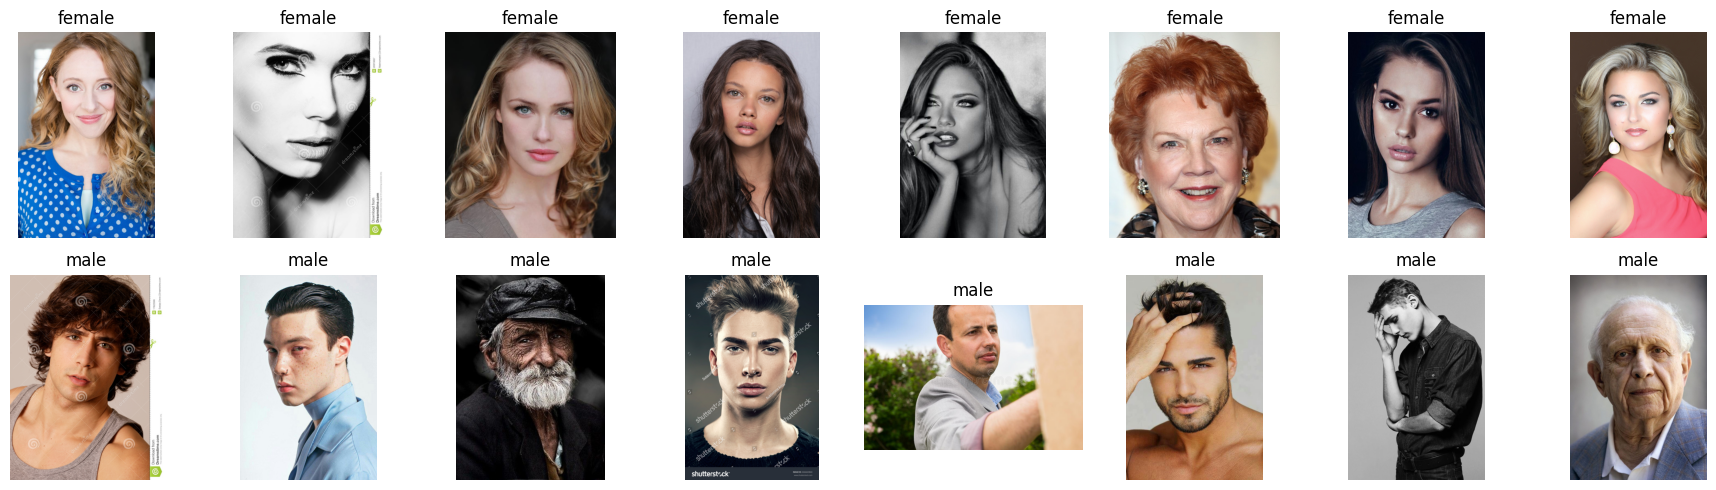

In [8]:
def get_image_files(class_name, max_images=8):
    class_dir = DATA_DIR / class_name
    files = [
        file for file in class_dir.rglob("*")
        if file.suffix.lower() in image_extensions
    ]
    random.shuffle(files)
    return files[:max_images]


fig, axes = plt.subplots(2, 8, figsize=(18, 5))

for row, class_name in enumerate(expected_classes):
    sample_files = get_image_files(class_name, max_images=8)

    for col, file in enumerate(sample_files):
        image = Image.open(file).convert("RGB")
        axes[row, col].imshow(image)
        axes[row, col].axis("off")
        axes[row, col].set_title(class_name)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "dataset_examples.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Carga del dataset y partición 70/15/15

Se construye la lista de rutas y etiquetas a **nivel de archivo** y luego se divide con `train_test_split` **estratificado por clase** en:

- 70% entrenamiento.
- 15% validación.
- 15% prueba.

El split a nivel de archivo (en lugar de hacerlo sobre un dataset ya batcheado con `take/skip`) garantiza:

- Estratificación real por clase en cada partición.
- Reproducibilidad determinista con la semilla.
- Que ninguna imagen aparezca en más de una partición.

Después se construyen los `tf.data.Dataset` a partir de cada lista, decodificando, redimensionando a `224x224` y normalizando a `[0, 1]` (mismo preprocesamiento que el backend).


In [9]:
from sklearn.model_selection import train_test_split

# Recolectamos rutas y etiquetas a nivel de archivo (no a nivel de batch).
# Esto permite un split estratificado y determinista, evitando el sesgo de
# particionar un dataset ya batcheado.
files, labels = [], []
for label, class_name in enumerate(expected_classes):  # 0=female, 1=male
    class_dir = DATA_DIR / class_name
    for file in sorted(class_dir.rglob("*")):
        if file.suffix.lower() in image_extensions:
            files.append(str(file))
            labels.append(label)

# 70% train, 15% val, 15% test, estratificado por clase.
train_files, tmp_files, train_labels, tmp_labels = train_test_split(
    files, labels,
    test_size=0.30,
    stratify=labels,
    random_state=SEED,
)
val_files, test_files, val_labels, test_labels = train_test_split(
    tmp_files, tmp_labels,
    test_size=0.50,
    stratify=tmp_labels,
    random_state=SEED,
)

class_names = expected_classes  # ['female', 'male']

print("Class names:", class_names)
print(f"Total imágenes: {len(files)}")
print(f"Train: {len(train_files)} (female={train_labels.count(0)}, male={train_labels.count(1)})")
print(f"Val:   {len(val_files)}  (female={val_labels.count(0)}, male={val_labels.count(1)})")
print(f"Test:  {len(test_files)}  (female={test_labels.count(0)}, male={test_labels.count(1)})")


Class names: ['female', 'male']
Total imágenes: 5418
Train: 3792 (female=1888, male=1904)
Val:   813  (female=405, male=408)
Test:  813  (female=405, male=408)


In [10]:
AUTOTUNE = tf.data.AUTOTUNE


def decode_image(path, label):
    """
    Lee una imagen desde disco, la decodifica como RGB, redimensiona a IMG_SIZE
    y normaliza dividiendo por 255 (mismo preprocesamiento que el backend).
    """
    raw = tf.io.read_file(path)
    img = tf.io.decode_image(raw, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, tf.cast(label, tf.float32)


def make_dataset(paths, ys, training):
    ds = tf.data.Dataset.from_tensor_slices((paths, ys))
    ds = ds.map(decode_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(buffer_size=2048, seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_ds = make_dataset(train_files, train_labels, training=True)
val_ds   = make_dataset(val_files,   val_labels,   training=False)
test_ds  = make_dataset(test_files,  test_labels,  training=False)

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches:  ", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches: ", tf.data.experimental.cardinality(test_ds).numpy())


2026-05-01 17:19:41.747366: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-05-01 17:19:41.747919: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-05-01 17:19:41.747932: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
I0000 00:00:1777673981.748435 1102019 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1777673981.748542 1102019 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Train batches: 119
Val batches:   26
Test batches:  26


## 6. Optimización del pipeline

La normalización dividiendo por 255 ya se aplicó dentro de `decode_image` (paso anterior), de la misma forma que lo hace el backend. Aquí solo cacheamos los datasets de validación y prueba para acelerar el entrenamiento.


In [11]:
# Cache solo en val/test (datos sin augmentación, no cambian entre épocas).
# El train_ds ya hace shuffle dentro de make_dataset() y NO se cachea para
# que el shuffle se reaplique cada época.
val_ds  = val_ds.cache()
test_ds = test_ds.cache()


## 7. Aumento de datos

El aumento de datos se aplica únicamente al conjunto de entrenamiento. Esto ayuda a reducir sobreajuste.

In [10]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomRotation(0.15, seed=SEED),
        layers.RandomZoom(0.2, seed=SEED),
        layers.RandomTranslation(0.1, 0.1, seed=SEED),
        layers.RandomContrast(0.2, seed=SEED),
        # Las imágenes ya están en [0, 1], por eso value_range=(0, 1).
        layers.RandomBrightness(0.2, value_range=(0.0, 1.0), seed=SEED),
    ],
    name="data_augmentation",
)


## 8. Construcción de la CNN desde cero

La arquitectura usa al menos tres bloques `Conv2D + MaxPooling2D`, activaciones ReLU, `Dropout` y salida sigmoide para clasificación binaria.

In [21]:
from tensorflow.keras import regularizers


def build_cnn_model(input_shape=(224, 224, 3), learning_rate=1e-4, dropout_rate=0.5):
    model = keras.Sequential()
    
    # Capas convolucionales
    model.add(
        keras.layers.Conv2D(
            32, 
            kernel_size = (3, 3),
            activation = 'relu',
            input_shape = input_shape
        )
    )
    model.add( keras.layers.MaxPooling2D(pool_size = (2, 2)) )
    model.add(
        keras.layers.Conv2D(
            64, 
            kernel_size = (3, 3),
            activation = 'relu'
        )
    )
    model.add( keras.layers.MaxPooling2D(pool_size = (2, 2)) )
    
    model.add( keras.layers.Flatten() )
    
    # Capas normalitas
    model.add( keras.layers.Dense(128, activation = 'relu') )
    model.add( keras.layers.Dropout(dropout_rate) )

    model.add( keras.layers.Dense(64, activation = 'relu') )
    model.add( keras.layers.Dropout(dropout_rate) )

    # Clasificación binaria: una sola neurona sigmoide.
    # La etiqueta es escalar (0=female, 1=male) y la pérdida es binary_crossentropy.
    model.add( keras.layers.Dense(1, activation = 'sigmoid') )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc"),
        ],
    )

    return model


model = build_cnn_model(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    learning_rate=1e-4,
    dropout_rate=0.5,
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,915,713 (91.23 MB)

 Trainable params: 23,915,713 (91.23 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Callbacks de entrenamiento

In [22]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10,
        min_delta=1e-4,
        restore_best_weights=True,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(MODEL_PATH),
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy",
        factor=0.5,
        patience=4,
        min_lr=1e-7,
    ),
    keras.callbacks.CSVLogger(str(REPORTS_DIR / "training_log.csv")),
]


## 10. Entrenamiento

In [23]:
# Verificar disponibilidad de GPU Metal
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print(f"GPU disponible: {gpus}")
else:
    print("ADVERTENCIA: No se detectó GPU. El entrenamiento correrá en CPU.")
    print("Asegurate de usar el kernel Python 3.12 (tf-metal) y tener tensorflow-metal instalado.")


GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [24]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/10


2026-05-01 17:26:18.240608: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1596 of 2048
2026-05-01 17:26:21.190060: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


119/119 ━━━━━━━━━━━━━━━━━━━━ 43s 234ms/step - accuracy: 0.5377 - auc: 0.5557 - loss: 1.0094 - precision: 0.5402 - recall: 0.5326 - val_accuracy: 0.7282 - val_auc: 0.8242 - val_loss: 0.5842 - val_precision: 0.7343 - val_recall: 0.7181 - learning_rate: 1.0000e-04
Epoch 2/10


2026-05-01 17:27:00.342053: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1585 of 2048
2026-05-01 17:27:03.339574: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


119/119 ━━━━━━━━━━━━━━━━━━━━ 41s 221ms/step - accuracy: 0.5949 - auc: 0.6307 - loss: 0.8862 - precision: 0.5998 - recall: 0.5809 - val_accuracy: 0.7368 - val_auc: 0.8635 - val_loss: 0.5370 - val_precision: 0.9409 - val_recall: 0.5074 - learning_rate: 1.0000e-04
Epoch 3/10


...

119/119 ━━━━━━━━━━━━━━━━━━━━ 39s 212ms/step - accuracy: 0.8059 - auc: 0.8908 - loss: 0.5279 - precision: 0.8160 - recall: 0.7920 - val_accuracy: 0.8856 - val_auc: 0.9539 - val_loss: 0.2828 - val_precision: 0.9070 - val_recall: 0.8603 - learning_rate: 1.0000e-04
Epoch 9/10


2026-05-01 17:31:47.028956: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1530 of 2048
2026-05-01 17:31:50.284071: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


119/119 ━━━━━━━━━━━━━━━━━━━━ 39s 212ms/step - accuracy: 0.8310 - auc: 0.9055 - loss: 0.5147 - precision: 0.8322 - recall: 0.8309 - val_accuracy: 0.8758 - val_auc: 0.9591 - val_loss: 0.3103 - val_precision: 0.9324 - val_recall: 0.8113 - learning_rate: 1.0000e-04
Epoch 10/10


2026-05-01 17:32:26.079965: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1585 of 2048
2026-05-01 17:32:29.179267: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


119/119 ━━━━━━━━━━━━━━━━━━━━ 41s 226ms/step - accuracy: 0.8697 - auc: 0.9318 - loss: 0.4140 - precision: 0.8782 - recall: 0.8598 - val_accuracy: 0.9041 - val_auc: 0.9722 - val_loss: 0.2385 - val_precision: 0.9533 - val_recall: 0.8505 - learning_rate: 1.0000e-04


## 11. Curvas de entrenamiento

In [25]:
history_df = pd.DataFrame(history.history)
history_df.to_csv(REPORTS_DIR / "training_history.csv", index=False)
history_df.head()

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
0,0.537711,0.555694,1.009352,0.540224,0.532563,0.728167,0.824174,0.584196,0.734336,0.718137,0.0001
1,0.594937,0.630727,0.886168,0.599783,0.580882,0.736777,0.863514,0.537045,0.940909,0.507353,0.0001
2,0.667458,0.734114,0.782884,0.677135,0.645483,0.742927,0.871998,0.542680,0.679279,0.924020,0.0001
3,0.699103,0.764548,0.897689,0.705439,0.688025,0.755228,0.885842,0.515630,0.694600,0.914216,0.0001
4,0.743935,0.821751,0.646871,0.751754,0.731618,0.824108,0.908155,0.401031,0.803204,0.860294,0.0001


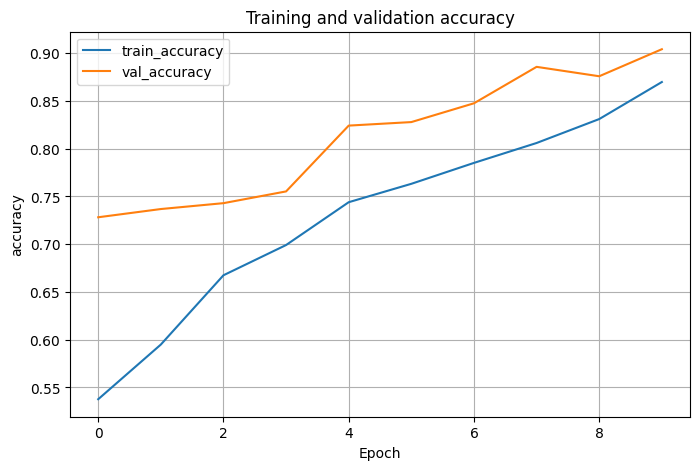

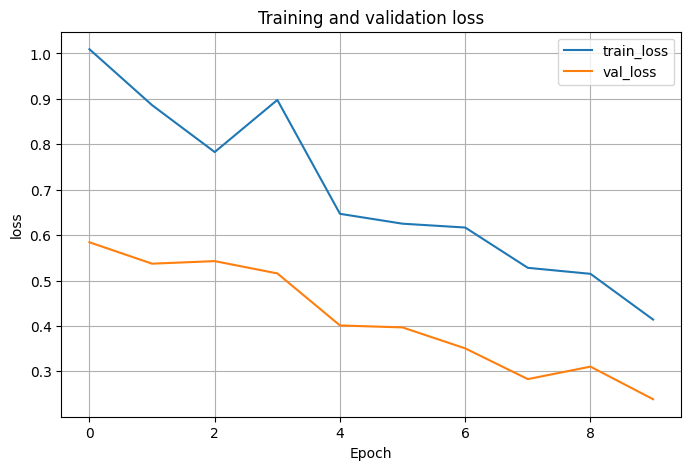

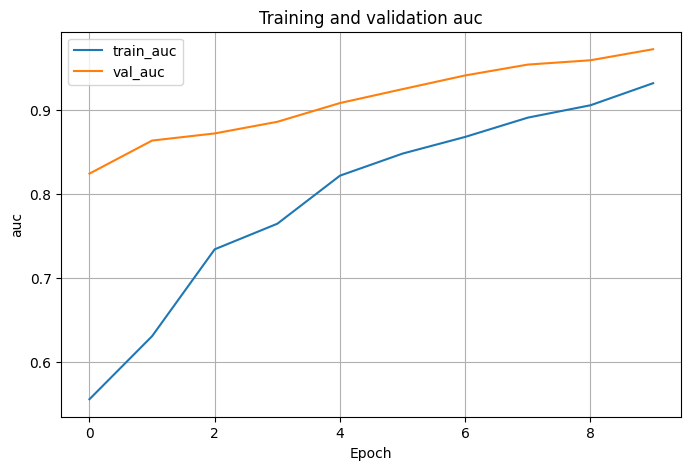

In [26]:
def plot_metric(history, metric_name, output_filename):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history[metric_name], label=f"train_{metric_name}")

    val_metric = f"val_{metric_name}"
    if val_metric in history.history:
        plt.plot(history.history[val_metric], label=val_metric)

    plt.xlabel("Epoch")
    plt.ylabel(metric_name)
    plt.title(f"Training and validation {metric_name}")
    plt.legend()
    plt.grid(True)
    plt.savefig(FIGURES_DIR / output_filename, dpi=150, bbox_inches="tight")
    plt.show()


plot_metric(history, "accuracy", "accuracy_curve.png")
plot_metric(history, "loss", "loss_curve.png")

if "auc" in history.history:
    plot_metric(history, "auc", "auc_curve.png")

## 12. Evaluación en el conjunto de prueba

In [27]:
test_metrics = model.evaluate(test_ds, return_dict=True)
test_metrics

26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.9077 - auc: 0.9703 - loss: 0.2508 - precision: 0.9612 - recall: 0.8505


{'accuracy': 0.9077490568161011,
 'auc': 0.9703006744384766,
 'loss': 0.250805139541626,
 'precision': 0.9612188339233398,
 'recall': 0.8504902124404907}

In [28]:
y_true = []
y_prob = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_prob.extend(preds.ravel().tolist())
    y_true.extend(labels.numpy().ravel().tolist())

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

print("Class names:", class_names)
print(classification_report(y_true, y_pred, target_names=class_names))

Class names: ['female', 'male']
              precision    recall  f1-score   support

      female       0.87      0.97      0.91       405
        male       0.96      0.85      0.90       408

    accuracy                           0.91       813
   macro avg       0.91      0.91      0.91       813
weighted avg       0.91      0.91      0.91       813



2026-05-01 17:38:23.059072: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names,
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix - Test Set")
plt.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Verificación de guardado y carga del modelo

Esta celda confirma que el archivo `model.keras` puede cargarse desde cero. Esto es importante porque el backend FastAPI usará exactamente este archivo.

In [ ]:
loaded_model = keras.models.load_model(MODEL_PATH)
loaded_model.summary()

In [ ]:
loaded_metrics = loaded_model.evaluate(test_ds, return_dict=True)
loaded_metrics

## 14. Selección de una imagen correctamente clasificada

Esta imagen se usará para Grad-CAM y Saliency Map.

In [ ]:
def get_correctly_classified_sample(model, dataset):
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        pred_labels = (preds.ravel() >= 0.5).astype(int)
        true_labels = labels.numpy().ravel().astype(int)

        for i in range(len(true_labels)):
            if pred_labels[i] == true_labels[i]:
                return images[i:i+1], int(true_labels[i]), float(preds.ravel()[i])

    raise ValueError("No se encontró una imagen correctamente clasificada.")


sample_image_batch, sample_true_label, sample_probability = get_correctly_classified_sample(
    loaded_model,
    test_ds,
)

sample_pred_label = int(sample_probability >= 0.5)

print("True label:", sample_true_label, class_names[sample_true_label])
print("Predicted label:", sample_pred_label, class_names[sample_pred_label])
print("Probability for positive class:", sample_probability)

In [ ]:
sample_image = sample_image_batch[0].numpy()

plt.figure(figsize=(5, 5))
plt.imshow(sample_image)
plt.axis("off")
plt.title(
    f"True: {class_names[sample_true_label]} | "
    f"Pred: {class_names[sample_pred_label]} | "
    f"p={sample_probability:.4f}"
)
plt.savefig(FIGURES_DIR / "correctly_classified_sample.png", dpi=150, bbox_inches="tight")
plt.show()

## 15. Grad-CAM

Grad-CAM muestra qué regiones de una capa convolucional profunda aportaron más a la predicción del modelo.

In [ ]:
import cv2


def find_last_conv_layer_name(model):
    for layer in reversed(model.layers):
        if isinstance(layer, layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found.")


def make_gradcam_heatmap(image_batch, model, last_conv_layer_name=None):
    if last_conv_layer_name is None:
        last_conv_layer_name = find_last_conv_layer_name(model)

    grad_model = keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output,
        ],
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image_batch)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    max_value = tf.reduce_max(heatmap)

    if max_value == 0:
        return heatmap.numpy()

    heatmap = heatmap / max_value

    return heatmap.numpy()


def overlay_heatmap_on_image(image_float, heatmap, alpha=0.4):
    image_uint8 = np.uint8(255 * image_float)

    heatmap_resized = cv2.resize(
        heatmap,
        (image_uint8.shape[1], image_uint8.shape[0]),
    )

    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(image_uint8, 1 - alpha, heatmap_color, alpha, 0)

    return overlay


last_conv_layer_name = find_last_conv_layer_name(loaded_model)
print("Last Conv2D layer:", last_conv_layer_name)

gradcam_heatmap = make_gradcam_heatmap(
    sample_image_batch,
    loaded_model,
    last_conv_layer_name=last_conv_layer_name,
)

gradcam_overlay = overlay_heatmap_on_image(sample_image, gradcam_heatmap, alpha=0.4)

plt.figure(figsize=(6, 6))
plt.imshow(gradcam_overlay)
plt.axis("off")
plt.title("Grad-CAM")
plt.savefig(FIGURES_DIR / "gradcam_sample.png", dpi=150, bbox_inches="tight")
plt.show()

## 16. Saliency Map

El Saliency Map calcula la sensibilidad de la predicción respecto a los píxeles de entrada.

In [ ]:
def make_saliency_map(image_batch, model):
    input_tensor = tf.convert_to_tensor(image_batch)

    with tf.GradientTape() as tape:
        tape.watch(input_tensor)
        predictions = model(input_tensor)
        loss = predictions[:, 0]

    gradients = tape.gradient(loss, input_tensor)
    saliency = tf.reduce_max(tf.abs(gradients), axis=-1)[0]

    saliency = saliency.numpy()
    max_value = np.max(saliency)

    if max_value > 0:
        saliency = saliency / max_value

    return saliency


def overlay_saliency_on_image(image_float, saliency, alpha=0.4):
    image_uint8 = np.uint8(255 * image_float)

    saliency_resized = cv2.resize(
        saliency,
        (image_uint8.shape[1], image_uint8.shape[0]),
    )

    saliency_uint8 = np.uint8(255 * saliency_resized)
    saliency_color = cv2.applyColorMap(saliency_uint8, cv2.COLORMAP_HOT)
    saliency_color = cv2.cvtColor(saliency_color, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(image_uint8, 1 - alpha, saliency_color, alpha, 0)

    return overlay


saliency = make_saliency_map(sample_image_batch, loaded_model)
saliency_overlay = overlay_saliency_on_image(sample_image, saliency, alpha=0.4)

plt.figure(figsize=(6, 6))
plt.imshow(saliency_overlay)
plt.axis("off")
plt.title("Saliency Map")
plt.savefig(FIGURES_DIR / "saliency_sample.png", dpi=150, bbox_inches="tight")
plt.show()

## 17. Comparación visual final

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(sample_image)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(gradcam_overlay)
axes[1].set_title("Grad-CAM")
axes[1].axis("off")

axes[2].imshow(saliency_overlay)
axes[2].set_title("Saliency Map")
axes[2].axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "xai_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 18. Experimentos de hiperparámetros

El laboratorio pide comparar al menos dos configuraciones. Esta sección entrena dos modelos pequeños cambiando `learning_rate` y `dropout_rate`.

Si el tiempo de entrenamiento es alto, puedes reducir `EPOCHS_EXPERIMENT` a 5.

In [ ]:
EPOCHS_EXPERIMENT = 8

experiments = [
    {
        "name": "cnn_lr_1e_4_dropout_0_4",
        "learning_rate": 1e-4,
        "dropout_rate": 0.4,
    },
    {
        "name": "cnn_lr_5e_4_dropout_0_5",
        "learning_rate": 5e-4,
        "dropout_rate": 0.5,
    },
]

experiment_results = []

for experiment in experiments:
    print("Running experiment:", experiment["name"])

    exp_model = build_cnn_model(
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
        learning_rate=experiment["learning_rate"],
        dropout_rate=experiment["dropout_rate"],
    )

    exp_history = exp_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_EXPERIMENT,
        verbose=1,
    )

    exp_metrics = exp_model.evaluate(test_ds, return_dict=True, verbose=0)

    experiment_results.append({
        "name": experiment["name"],
        "learning_rate": experiment["learning_rate"],
        "dropout_rate": experiment["dropout_rate"],
        "test_loss": exp_metrics.get("loss"),
        "test_accuracy": exp_metrics.get("accuracy"),
        "test_precision": exp_metrics.get("precision"),
        "test_recall": exp_metrics.get("recall"),
        "test_auc": exp_metrics.get("auc"),
    })

experiments_df = pd.DataFrame(experiment_results)
experiments_df.to_csv(REPORTS_DIR / "hyperparameter_experiments.csv", index=False)
experiments_df

## 19. Resumen para el informe

Puedes usar estos elementos en el entregable manuscrito:

- Descripción del dataset.
- Tabla de número de imágenes por clase.
- Mosaico de imágenes representativas.
- Descripción del preprocesamiento.
- Arquitectura de la CNN.
- Curvas de entrenamiento y validación.
- Matriz de confusión.
- Tabla de experimentos de hiperparámetros.
- Visualizaciones Grad-CAM y Saliency Map.
- Análisis ético sobre sesgos del dataset.

In [ ]:
print("Modelo guardado en:", MODEL_PATH)
print("Figuras guardadas en:", FIGURES_DIR)
print("Historial de entrenamiento:", REPORTS_DIR / "training_history.csv")
print("Experimentos:", REPORTS_DIR / "hyperparameter_experiments.csv")